# Изучение рынка заведений общественного питания Москвы

Дата: 25.05.2026

---
## Общие сведения
### Цель и задачи проекта
**Цель**

Провести исследование и подготовить отчет по результатам для выбора подходящего места для нового места общественного питания в Москве

**Задачи**
* Получить общую информацию о данных;
* Провести предобработку данных;
* Провести анализ предобработаных данных;
* Провести анализ закономерностей;
* Подготовить выводы.


### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
* `name` — название заведения;
* `address` — адрес заведения;
* `district` — административный район, в котором находится заведение, например Центральный административный округ;
* `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
* `hours` — информация о днях и часах работы;
* `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
* `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
  * 0 — заведение не является сетевым;
  * 1 — заведение является сетевым.
* `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
* `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
* `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
  * «Средний счёт: 1000–1500 ₽»;
  * «Цена чашки капучино: 130–220 ₽»;
  * «Цена бокала пива: 400–600 ₽».
  * и так далее;
* `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
  * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  * Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
* `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
  * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  * Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними;
2. Предобработка данных;
3. Исследовательский анализ данных;
4. Итоговые выводы.

---
## Загрузка данных и знакомство с ними
### Загрузка данных

Импортируем необходимые нам для работы библиотеки

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix 

Загрузим данные и познакомимся с ними.
Выгружаем данные в переменные `rest_info_df` и `rest_price_df`.

In [2]:
# Выгружаем данные в переменные rest_info_df и rest_price_df
rest_info_df = pd.read_csv('rest_info.csv')
rest_price_df = pd.read_csv('rest_price.csv')

### Знакомство с данными
Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()` и информацию методом `info()`.

In [3]:
# Выводим первые строки датафрейма rest_info_df на экран
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим общую информацию о датафрейме rest_info_df
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Познакомимся с данными датасета rest_price.csv — выведем первые строки методом head() и информацию методом info().

In [5]:
# Выводим первые строки датафрейма rest_price_df на экран
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим общую информацию о датафрейме rest_price_df
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


### Промежуточный вывод



**rest_info.csv**
* Датасет rest_info.csv содержит **8406** строк и **9** столбцов, в которых представлена информация о заведениях общественного питания;
* Данные представлены типами `object`, `int64` и `float64`;
* Данные столбца `chain` содержат значения **1** или **0** — размерность этих данных можно оптимизировать;
* Пропуски содержатся в столбцах `hours` и `seats`, однако следует проверить и другие столбцы, поскольку в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных;
* По предварительному знакомству предоставленные данные соответствуют описанию.

**rest_price.csv**
* Датасет rest_price.csv содержит **4058** строк и **5** столбцов, в которых представлена информация о среднем чеке в заведениях общественного питания;
* Данные представлены типами `object` и `float64`;
* Все столбцы с данными, кроме `id`, содержат пропуски;
* Нужно будет их проанализировать и принять решение о восстановлении/замене/удалении данных;
* Предоставленные данные соответствуют описанию.

**Оба датасета**

Невооруженным глазом видно, что данных в датасете `rest_price.csv` почти в 2 раза меньше, чем в `rest_info.csv`. Для полноты картины при решении задач с анализом цен нам нужно учитывать этот момент. Сейчас при объединении воспользуемся способом `left`, чтобы не потерять данные из датасета `rest_info.csv`. 

### Подготовка единого датафрейма

Соединим данные, используя значение параметра `how` по умолчанию — `left`. Это позволит сохранить данные из обоих датасетов.

In [7]:
# Объединяем датафреймы rest_info_df и rest_price_df с помощью merge по столбцу id и типу inner
df = rest_info_df.merge(rest_price_df, on = 'id', how = 'left')

In [8]:
# Выводим первые строки объединенного датафрейма df на экран
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [9]:
# Выводим общую информацию об объединенном датафрейме df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


### Вывод по этапу
Мы провели предварительное знакомство с датасетами `rest_info.csv` и `rest_price.csv`:
* Проверили, что данные в них совпадают с описанием;
* Оба датасета с разным размером, после объединения это важно учитывать, особенно при решении задач с ценами;
* Наименования в обоих датасетах в нормальном виде;
* Данные в столбцах нужно проверить и привести к единому стилю;
* Нужно проверить корректность типов данных, особенно `object` и оптимизировать столбцы с числовыми значениями.

---
## Предобработка данных

На этом этапе подготовим данным к исследовательскому анализу:
* Перепроверим именования столбцов;
* Перепроверим типы данные в столбцах, особенно в `object`.

### Проверка именования столбцов
Перепроверим стиль наименования столбцов

In [10]:
# Проверим наименования столбцов
df.columns

Index(['id', 'name', 'category', 'address', 'district', 'hours', 'rating',
       'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill',
       'middle_coffee_cup'],
      dtype='object')

С наименованием столбцов все в порядке, переходим к проверке типов данных.

### Оптимизация типов данных

In [11]:
# Перенесем наименование столбцов в единый список
object_types_columns = df.columns.tolist()

# Создадим функцию проверки типов данных в столбце
def check_unique_column_types(column_name):
    unique_types = df[f'{column_name}'].apply(type).unique().tolist()
    print(f'Используемые типы данных в столбце {column_name} - {unique_types}')

# Применим функцию к нашим столбцам
for element in object_types_columns:
    check_unique_column_types(element)

Используемые типы данных в столбце id - [<class 'str'>]
Используемые типы данных в столбце name - [<class 'str'>]
Используемые типы данных в столбце category - [<class 'str'>]
Используемые типы данных в столбце address - [<class 'str'>]
Используемые типы данных в столбце district - [<class 'str'>]
Используемые типы данных в столбце hours - [<class 'str'>, <class 'float'>]
Используемые типы данных в столбце rating - [<class 'float'>]
Используемые типы данных в столбце chain - [<class 'int'>]
Используемые типы данных в столбце seats - [<class 'float'>]
Используемые типы данных в столбце price - [<class 'float'>, <class 'str'>]
Используемые типы данных в столбце avg_bill - [<class 'float'>, <class 'str'>]
Используемые типы данных в столбце middle_avg_bill - [<class 'float'>]
Используемые типы данных в столбце middle_coffee_cup - [<class 'float'>]


Видим, что нужно поработать со следующими столбцами:
* hours - видим, что есть и `str` и `float`. Интересно посмотреть, какие данные там встречаются и как их привести к единому формату;
* price - проверим, что `float` взялся из-за пустых значений;
* avg_bill - проверим, что `float` взялся из-за пустых значений.

In [12]:
# Напишем функцию проверки уникальных значений с типом float
def check_float_type(column_name):
    float_values = set()
    for e in df[column_name]:
        if isinstance(e, float):
            float_values.add(e)
    print(f'Значения с типом float в {column_name} - {float_values}')

In [13]:
# Применим функцию check_float_type к интересующим нас столбцам
check_float_type('hours')
check_float_type('price')
check_float_type('avg_bill')

Значения с типом float в hours - {nan}
Значения с типом float в price - {nan}
Значения с типом float в avg_bill - {nan}


Видим, что разница в типах у нас возникла из-за пропуска в данных. Если мы сейчас столбцы `hours`, `price` и `avg_bill` будем преобразовать только в `str`, то у нас смешаются пропуски. Поэтому мы их не трогаем, но можем оптимизировать оптимизируем столбцы `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` и отдельно `chain`.

In [14]:
# Оптимизируем столбец chain
float_to_optimize = ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']

for column in float_to_optimize:
    df[column] = pd.to_numeric(df[column], downcast='float')
    
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [15]:
# Проверим
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 665.1+ KB


**Вывод по оптимизации типов**

У нас получилось оптимизировать только цулочисленный тип данных в столбце `chain` и данные с плавабщей точкой в `rating`, `seats`, `middle_avg_bill` и `middle_coffee_cup`. Остальные данные мы оставили как есть, но нужно внимательно их проверить на пропуски.

### Проверка пропусков в данных
- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [16]:
# Применяем метод isna() к датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [17]:
# Подсчитываем долю строк с пропусками
df_isna_ratio = round(df.isna().mean() * 100, 2)
df_isna_ratio

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

**Выводы по пропускам**

Исходный датасет сформирован на основе открытых данных сервисов Яндекс Карты и Яндекс Бизнес. Высокий процент пропусков в столбцах `seats` (42.96%), `price` (60.56%), `avg_bill` (54.60%), `middle_avg_bill` (62.54%) и `middle_coffee_cup` (93.64%) имеет под собой неслучайный характер (MNAR — Missing Not at Random). Т.е. по сути, заполнение этих данных основано либо на добровольной основе заведения (включая столбец `hours`), либо на основе отзывов клиентов.

Заполнение таких масштабных пропусков искусственными метриками (медианой или модой) приведет к **"сглаживанию"** данных, уничтожит реальную вариативность и исказит результаты анализа. Поскольку наличие пропусков обусловлено спецификой самих заведений, оставим данные **"как есть"** и будем обрабатывать пропуски уже под конкретную задачу, где эти столбцы критически необходимы.

Но предварительно проверим данные на дубликаты.

### Проверка дубликатов
Для проверки дубликатов приведем данные в столбцах `name`, `category`, `address`, `district`, `hours`, `price` и `avg_bill` к нижнему регистру.
- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [18]:
# Приведем нужные столбцы к нижнему регистру с помощью str.lower()
columns_to_lower_case = ['name', 'category', 'address', 'district', 'hours', 'price', 'avg_bill']

def data_to_lower_case(column):
    df[column] = df[column].str.lower()

for column in columns_to_lower_case:
    data_to_lower_case(column)

In [19]:
# Проверим, что изменения применились к датафрейму
df.head(10)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,sergio pizza,пиццерия,"москва, ижорская улица, вл8б",северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,огни города,"бар,паб","москва, клязьминская улица, 9, стр. 3",северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0,средние,средний счёт:199 ₽,199.0,NaN
7,0243288b78024af090b8e947842c969c,mr. уголёк,быстрое питание,"москва, клязьминская улица, 9, стр. 3",северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0,средние,средний счёт:200–300 ₽,250.0,NaN
8,36aeb0ffa69c48fdb0021549520deb10,donna maria,ресторан,"москва, дмитровское шоссе, 107, корп. 4",северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0,средние,средний счёт:от 500 ₽,500.0,NaN
9,487167877eb04288bc90d4fa80646fc2,готика,кафе,"москва, ангарская улица, 39",северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0,средние,средний счёт:1000–1200 ₽,1100.0,NaN


Нужные столбца к нужному регистру привели. Теперь проверим на явные и неявные дубликаты. Проверим сначала на полные дуликаты.

In [20]:
# Проверяем полные дубликаты в датафрейме
df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` заведений должны быть уникальными, то есть каждая строка в данных — уникальное заведение.

In [21]:
df.duplicated(subset='id').sum() 

np.int64(0)

Каждая строка соответствует уникальному заведению. Теперь проверим дубли в названиях

In [22]:
df.duplicated(subset='name').sum()

np.int64(2894)

А вот тут уже интереснее, но нужно проверить еще по адресу

In [23]:
df.duplicated(subset=['name', 'address']).sum()

np.int64(4)

У нас есть 4 дублирующие записи, не так много, но можно их проанализировать в отдельном датафрейме.

In [24]:
df_duplicated = df[df.duplicated(subset=['name', 'address'], keep = False) == True]
df_duplicated

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Для лучшей читаемости оставлю только столбцы с данными

In [25]:
df_duplicated = df_duplicated[['id', 'name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats']]
df_duplicated

,id,name,category,address,district,hours,rating,chain,seats
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,NaN,4.1,0,276.0


Что здесь можно увидеть:
* Заведения с номерами 189 и 215 вроде являются дубликатами с одинаковыми рейтингами, но у них различаются часы работы. В теории можно предположить, что по указанному в них адресу может находится и 2 кафе, поскольку точного здания там не указано. Все же допустим, что это дубликаты и удалим один лишний;
* 1430 и 1511 тоже вроде дубликаты, но с разным временем работы. Есть различия в принадлежности к сети. Нужно проверить;
* 2211 и 2420 идентичная ситуация, тоже нужно проверить на принадлежность к сети;
* 3091 и 3109 тоже проверить на принадлежность к сети и лучше взять то, у которого есть график.

Проверим заведения `more poke`, `раковарня клешни и хвосты` и `хлеб да выпечка` на принадлежность к сети.

In [26]:
df_filtered = df.loc[(df['name'] == 'more poke')]
df_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
6088,1cd73aca53414d65a7744da3d1c93832,more poke,ресторан,"москва, духовской переулок, 19",южный административный округ,"ежедневно, 10:00–22:00",4.4,1,NaN,NaN,NaN,NaN,NaN


In [27]:
df_filtered = df.loc[(df['name'] == 'раковарня клешни и хвосты')]
df_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,раковарня клешни и хвосты,"бар,паб","москва, братиславская улица, 12",юго-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,1,40.0,средние,цена бокала пива:150–250 ₽,NaN,NaN


In [28]:
df_filtered = df.loc[(df['name'] == 'хлеб да выпечка')]
df_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,хлеб да выпечка,кофейня,"москва, каширское шоссе, 61г",южный административный округ,"ежедневно, 09:00–22:00",4.5,1,NaN,NaN,NaN,NaN,NaN


Сделаем вывод, что все 3 заведения относятся к сетевым. Т.е. из дублей убираем не сетевые.

In [29]:
# Убираем дубли из данных
data_to_drop = [215, 1430, 2211, 3109]
df.drop(data_to_drop, inplace=True)

In [30]:
# Проверяем, что нужные нам дубли ушли
df_filtered = df.loc[ 
    (df['name'] == 'more poke') |
    (df['name'] == 'раковарня клешни и хвосты') |
    (df['name'] == 'хлеб да выпечка') 
]
df_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
6088,1cd73aca53414d65a7744da3d1c93832,more poke,ресторан,"москва, духовской переулок, 19",южный административный округ,"ежедневно, 10:00–22:00",4.4,1,NaN,NaN,NaN,NaN,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,раковарня клешни и хвосты,"бар,паб","москва, братиславская улица, 12",юго-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,1,40.0,средние,цена бокала пива:150–250 ₽,NaN,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,хлеб да выпечка,кофейня,"москва, каширское шоссе, 61г",южный административный округ,"ежедневно, 09:00–22:00",4.5,1,NaN,NaN,NaN,NaN,NaN


In [31]:
# Сверим оставшееся количество данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8402 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 730.3+ KB


Видим, что осталось 8402 строк из 8406 ранее. Теперь проверим корректность написания категориальных значений в данных.

In [32]:
for column in ['district', 'category']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique().tolist())
    print()

Уникальные значения в столбце district:
['восточный административный округ', 'западный административный округ', 'северный административный округ', 'северо-восточный административный округ', 'северо-западный административный округ', 'центральный административный округ', 'юго-восточный административный округ', 'юго-западный административный округ', 'южный административный округ']

Уникальные значения в столбце category:
['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']



В обозначениях региона и категории дублей нет, все хорошо. На этом работу с дублями завершим.

**Вывод по работе с дублями**

Мы проверили наш датафрейм `df` на явные и неявные дубли. Выявили 4 дублирующие строки и убрали их. В целом больше дублей нет, можно работать дальше.

### Столбец is_24_7

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.
  
Заведение, которое работает круглосуточно имее значение `круглосуточно` в столбце `hours`. Проверим, какие комбинации встречаются с этим значением. Пока не будем все делать в основном датафрейме, а проверим данные на отдельном.

In [33]:
df_is_24_7 = df.loc[df["hours"].str.contains("круглосуточно", case=False, na=False)]
df_is_24_7.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
10,ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,цена бокала пива:250–350 ₽,NaN,NaN
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана беш-бармак,ресторан,"москва, ленинградское шоссе, 71б, стр. 2",северный административный округ,"ежедневно, круглосуточно",4.4,0,96.0,средние,средний счёт:350–500 ₽,425.0,NaN
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",северный административный округ,"ежедневно, круглосуточно",4.4,1,NaN,NaN,NaN,NaN,NaN
24,0f5d22f5377340d0a81a9328e6ebdcac,drive café,кафе,"москва, улица дыбенко, 9ас1",северный административный округ,"ежедневно, круглосуточно",4.0,1,NaN,NaN,NaN,NaN,NaN
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва, ижорская улица, 8а",северный административный округ,"ежедневно, круглосуточно",2.7,0,NaN,NaN,средний счёт:900 ₽,900.0,NaN


Проверим значения, которые нам записались

In [34]:
df_is_24_7.info()

<class 'pandas.core.frame.DataFrame'>
Index: 772 entries, 10 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 772 non-null    object 
 1   name               772 non-null    object 
 2   category           772 non-null    object 
 3   address            772 non-null    object 
 4   district           772 non-null    object 
 5   hours              772 non-null    object 
 6   rating             772 non-null    float32
 7   chain              772 non-null    int8   
 8   seats              440 non-null    float32
 9   price              223 non-null    object 
 10  avg_bill           267 non-null    object 
 11  middle_avg_bill    238 non-null    float32
 12  middle_coffee_cup  22 non-null     float32
dtypes: float32(4), int8(1), object(8)
memory usage: 67.1+ KB


In [35]:
df_24_7_unique = df_is_24_7['hours'].unique().tolist()
df_24_7_unique

['ежедневно, круглосуточно',
 'пн 00:01–12:00, перерыв 12:00–13:30; вт-чт 13:30–12:00; пт 13:30–00:00; сб,вс круглосуточно',
 'вт-вс круглосуточно',
 'сб круглосуточно',
 'пт-вс круглосуточно',
 'пн,ср,чт,пт,сб,вс круглосуточно',
 'пн 10:00–00:00; вт-сб круглосуточно; вс 00:00–23:00',
 'пн-чт 07:30–23:00; пт 07:30–00:00; сб круглосуточно; вс 00:00–23:00',
 'пн круглосуточно; вт-чт 12:00–00:00; пт 12:00–02:00; сб 11:00–02:00; вс 14:00–00:00',
 'пн-чт 08:00–23:00; пт,сб круглосуточно; вс 08:00–23:00',
 'пн-ср 07:00–23:00; чт 07:00–00:00; пт,сб круглосуточно; вс 00:00–23:00',
 'пн-чт 08:00–23:00; пт 08:00–00:00; сб круглосуточно; вс 00:00–23:00',
 'пн 08:00–23:00; вт-пт 08:00–00:00; сб круглосуточно; вс 00:00–23:00',
 'пн-ср 09:00–00:00; чт-вс круглосуточно',
 'пн-чт круглосуточно; пт 00:00–05:00, перерыв 05:00–07:00; сб 07:00–05:00; вс 07:00–00:00',
 'пн-чт 11:00–23:00; пт 11:00–00:00; сб круглосуточно; вс 00:00–23:00',
 'пн,вт 08:00–22:00; ср,чт 08:00–23:00; пт,сб круглосуточно; вс 00:0

Вот тут можно увидеть, что нам нужно только одно комбинированное значение `ежедневно, круглосуточно`, т.е. просто по значению `круглосуточно` искать ошибочно. Применим такой отбор к основному датафрейму.

In [36]:
df["is_24_7"] = (
    df["hours"].str.contains("ежедневно", case=False, na=False) &
    df["hours"].str.contains("круглосуточно", case=False, na=False)
)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
 13  is_24_7            8402 non-null   bool   
dtypes: bool(1), float32(4), int8(1), object(8)
memory usage: 738.5+ KB


In [38]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,средний счёт:400–600 ₽,500.0,NaN,False


In [39]:
len(df.loc[df['is_24_7'] == True])

730

**Вывод по работе с дублями**

Мы добавили в основной датафрейм столбец `is_24_7` в котором пометели значением `True` только те заведения, которые работют ежедневно и круглосуточно. Всего таких заведений получилось 730. 

### Промежуточный вывод

1. Мы проверили именования столбцов, с ними никаких дествий делать не нужно было;
2. Оптимизировали только целочисленный тип данных в столбце chain и данные с плавабщей точкой в rating, seats, middle_avg_bill и middle_coffee_cup. Остальные данные мы оставили как есть;
3. Исходный датасет сформирован на основе открытых данных сервисов Яндекс Карты и Яндекс Бизнес. Высокий процент пропусков в столбцах seats (42.96%), price (60.56%), avg_bill (54.60%), middle_avg_bill (62.54%) и middle_coffee_cup (93.64%) имеет под собой неслучайный характер (MNAR — Missing Not at Random). Т.е. по сути, заполнение этих данных основано либо на добровольной основе заведения (включая столбец hours), либо на основе отзывов клиентов. Заполнение таких масштабных пропусков искусственными метриками (медианой или модой) приведет к "сглаживанию" данных, уничтожит реальную вариативность и исказит результаты статистических тестов. Поскольку природа пропусков обусловлена спецификой самих заведений, принято решение оставить данные "как есть" и обрабатывать пропуски под конкретную задачу, где эти столбцы критически необходимы;
4. Мы проверили наш датафрейм df на явные и неявные дубли. Выявили 4 дублирующие строки и убрали их;
5. Мы добавили в основной датафрейм столбец is_24_7 в котором пометели значением True только те заведения, которые работют ежедневно и круглосуточно. Всего таких заведений получилось 730.

---
## Исследовательский анализ данных

Проведем исследовательский анализ данных.

### Задача 1
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.</div>

Посмотрим, какие категории у нас присутствуют

In [40]:
# Сделаем список категорий и выведем его на экран
category = df['category'].unique().tolist()
for index, cat in enumerate(category):
    print(f'{index}. {cat}')

0. кафе
1. ресторан
2. кофейня
3. пиццерия
4. бар,паб
5. быстрое питание
6. булочная
7. столовая


Теперь посчитаем количество объектов для каждой категории

In [41]:
df['category'].value_counts()

category
кафе               2376
ресторан           2041
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

Выведем красивую визуализацию в виде столбчатой диаграммы

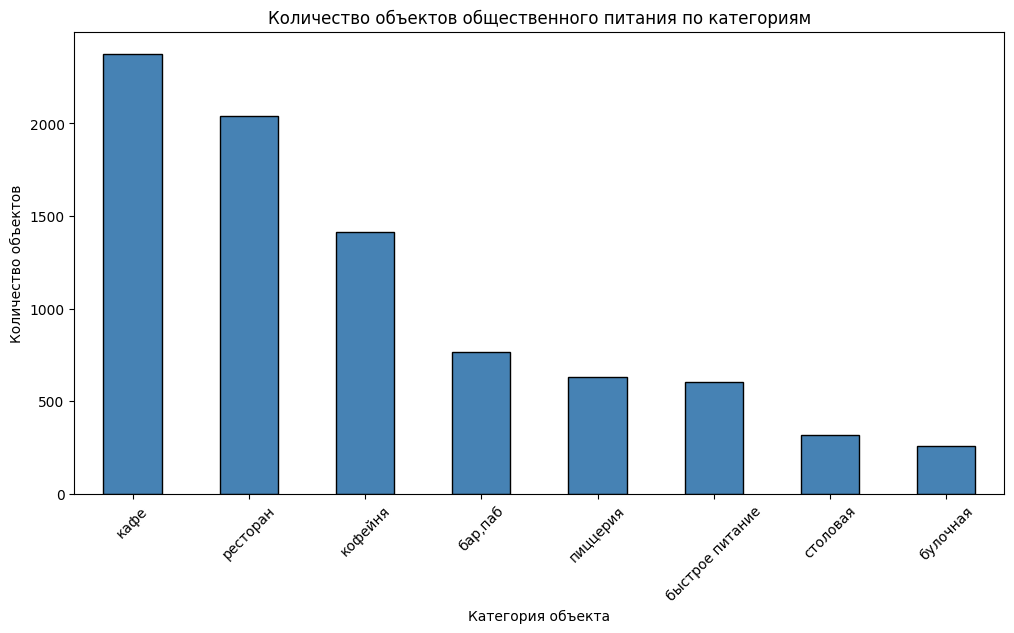

In [42]:
df['category'].value_counts().plot(
    kind='bar',
    figsize=(12, 6),
    title='Количество объектов общественного питания по категориям',
    legend=False,
    ylabel='Количество объектов',
    xlabel='Категория объекта',
    rot=45,
    color='#4682B4',
    edgecolor='black'
)
plt.show()

**Вывод по задаче**

Мы посмотрели, какими категориями у нас представленны данные и сколько объектов находиться в каждой категории. Видим, что в категории `кафе` самое большое количество объектов - **2376**.

---

### Задача 2
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.</div>

Посмотрим, какие районы у нас присутствуют

In [43]:
# Сделаем список районов и выведем его на экран
category = df['district'].unique().tolist()
for index, cat in enumerate(category):
    print(f'{index}. {cat}')

0. северный административный округ
1. северо-восточный административный округ
2. северо-западный административный округ
3. западный административный округ
4. центральный административный округ
5. восточный административный округ
6. юго-восточный административный округ
7. южный административный округ
8. юго-западный административный округ


**Распределение количества заведений по административным районам Москвы**

Теперь приверим количество объектов для каждого района

In [44]:
df['district'].value_counts()

district
центральный административный округ         2242
северный административный округ             898
южный административный округ                892
северо-восточный административный округ     890
западный административный округ             850
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: count, dtype: int64

Выведем красивую визуализацию в виде столбчатой диаграммы

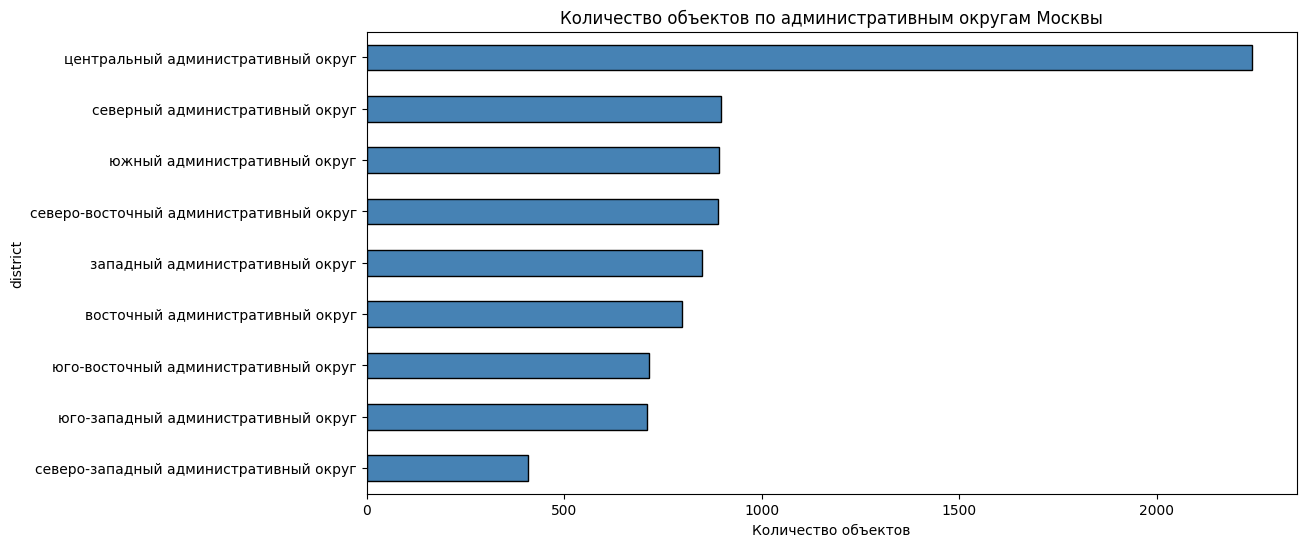

In [45]:
df['district'].value_counts().sort_values(ascending=True).plot(
    kind='barh',
    figsize=(12, 6),
    title='Количество объектов по административным округам Москвы',
    legend=False,
    color='#4682B4',
    edgecolor='black'
)
plt.xlabel('Количество объектов')
plt.show()

**Распределение заведений каждой категории в Центральном административном округе Москвы**



Сделаем сводную таблицу по округам и категориям с подсчетом количества объектов

In [46]:
pivot_district = pd.pivot_table(df, values='id', index=['district', 'category'], aggfunc='count')
pivot_district

id
district                         category            
восточный административный округ бар,паб           53
                                 булочная          25
                                 быстрое питание   71
                                 кафе             272
                                 кофейня          105
...                                               ...
южный административный округ     кафе             264
                                 кофейня          131
                                 пиццерия          73
                                 ресторан         202
                                 столовая          44

[72 rows x 1 columns]

Отфильтруем данные только по центральному административному округу

In [47]:
filtered_pivot_district = pivot_district.loc['центральный административный округ']
filtered_pivot_district

,id
category,
"бар,паб",364
булочная,50
быстрое питание,87
кафе,464
кофейня,428
пиццерия,113
ресторан,670
столовая,66


Поменяем название столбца на `count`.

In [48]:
filtered_pivot_district.columns = ['count']
filtered_pivot_district

,count
category,
"бар,паб",364
булочная,50
быстрое питание,87
кафе,464
кофейня,428
пиццерия,113
ресторан,670
столовая,66


Выведем данные в виде столбчатой диаграммы с сортировкой данных по убыванию.

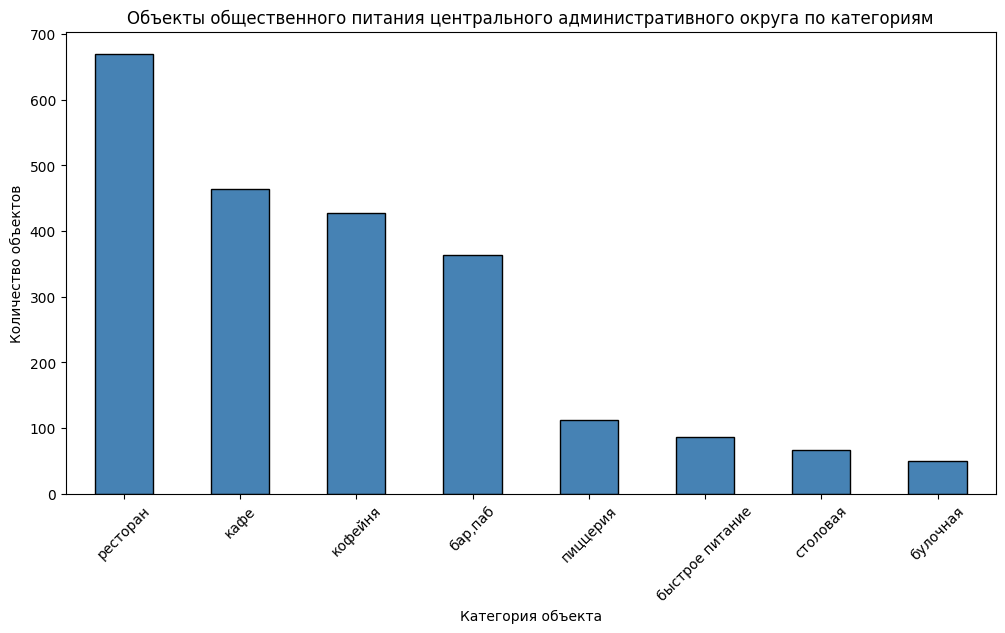

In [49]:
filtered_pivot_district.sort_values(by='count', ascending=False).plot(
    kind='bar',
    figsize=(12, 6),
    title='Объекты общественного питания центрального административного округа по категориям',
    legend=False,
    ylabel='Количество объектов',
    xlabel='Категория объекта',
    rot=45,
    color='#4682B4',
    edgecolor='black'
)
    
plt.show()

**Вывод по задаче**

Мы подсчитали количество объектов по округам Москвы - самое большое количество в центральном административном округе, **2242** объекта. А в самом центральном административном округе самая большая категория объектов - это рестораны, **670** объектов.

---

### Задача 3
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.</div>

Подсчитаем количество сетевых и несетевых заведений

In [50]:
pivot_chain = pd.pivot_table(df, values='id', index='chain', aggfunc='count')
pivot_chain.columns = ['count']
pivot_chain['ratio'] = round(pivot_chain['count'] / pivot_chain['count'].sum() * 100, 2)
pivot_chain

,count,ratio
chain,,
0,5197,61.85
1,3205,38.15


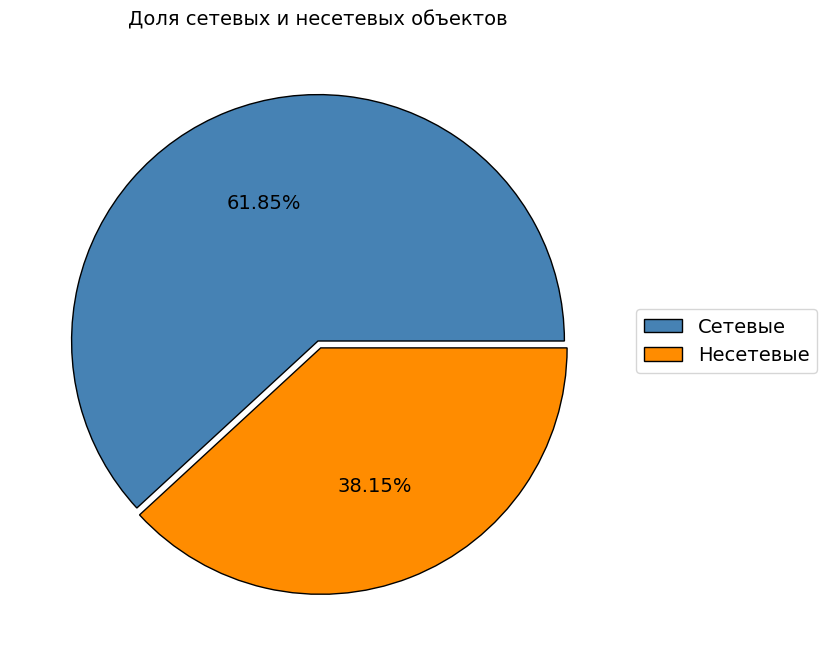

In [51]:
pivot_chain['count'].plot(
    kind='pie',
    figsize=(8, 8),
    explode=(0, 0.03),
    legend=True,
    labels=None,
    autopct='%1.2f%%',
    ylabel='',
    colors=['#4682B4', '#FF8C00'],
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 14}
)
plt.legend(['Сетевые', 'Несетевые'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.title('Доля сетевых и несетевых объектов', fontsize=14)
plt.show()

Видим, что сетевых объектов (61.85%) намного больше, чем не сетевых (38.15%).

Соберем таблицу с подсчетом доли сетевых заведений из общего числа заведений.

In [52]:
pivot = pd.pivot_table(
    df,
    values='id',
    index='category',
    columns='chain',
    aggfunc='count',
    fill_value=0
)
pivot['chain_1_ratio'] = round(pivot[1] / (pivot[0] + pivot[1]), 2)
pivot['chain_2_ratio'] = round(pivot[0] / (pivot[0] + pivot[1]), 2)
pivot

chain,0,1,chain_1_ratio,chain_2_ratio
category,,,,
"бар,паб",596,169,0.22,0.78
булочная,99,157,0.61,0.39
быстрое питание,371,232,0.38,0.62
кафе,1597,779,0.33,0.67
кофейня,693,720,0.51,0.49
пиццерия,303,330,0.52,0.48
ресторан,1311,730,0.36,0.64
столовая,227,88,0.28,0.72


Упростим себе задачу, сделаем наглядный датафрей для дальнейшей красивой визуализации.

In [53]:
df_chain_plot = pd.DataFrame({
    'chain_1_ratio': pivot['chain_1_ratio'],
    'chain_2_ratio': pivot['chain_2_ratio']
}).sort_values('chain_1_ratio', ascending=False)
df_chain_plot

,chain_1_ratio,chain_2_ratio
category,,
булочная,0.61,0.39
пиццерия,0.52,0.48
кофейня,0.51,0.49
быстрое питание,0.38,0.62
ресторан,0.36,0.64
кафе,0.33,0.67
столовая,0.28,0.72
"бар,паб",0.22,0.78


Построим столбчатую диаграмму для наглядного отображения доли сетевых заведений в разрезе категорий.

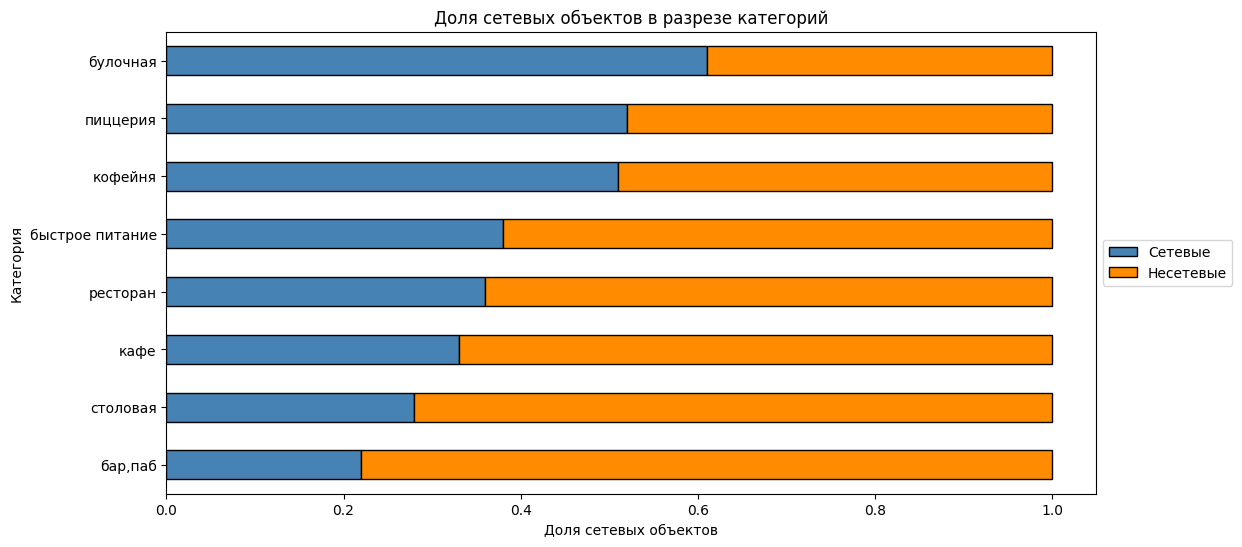

In [54]:
# Строим столбчатую диаграмму
df_chain_plot.sort_values(by='chain_1_ratio', ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    title='Доля сетевых объектов в разрезе категорий',
    legend=False,
    rot=0,
    color=['#4682B4', '#FF8C00'],
    edgecolor='black'
)
plt.xlabel('Доля сетевых объектов')
plt.ylabel('Категория')
plt.legend(['Сетевые', 'Несетевые'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Здесь наблюдается интересная картина, мы видим, что 3 категории `булочная`, `пиццерия` и `кофейня` чаще являются сетевыми.

**Вывод по задаче**

По общей картине мы видим, что сетевых заведений намного больше, чем не сетевых - **61.85%** против **38.15%**.
В разрезе категорий чаще всего сетевыми являются `булочная`, `пиццерия` и `кофейня`.

---

### Задача 4
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.</div>


Поскольку у нас в столбце seats встречаются пустые значения, мы сделаем для изучения отдельный датафрейм только с теми строками, где значение seats не пустое.

In [55]:
df_seats = df.loc[df['seats'].notna()]
df_seats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4792 entries, 1 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4792 non-null   object 
 1   name               4792 non-null   object 
 2   category           4792 non-null   object 
 3   address            4792 non-null   object 
 4   district           4792 non-null   object 
 5   hours              4493 non-null   object 
 6   rating             4792 non-null   float32
 7   chain              4792 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              2050 non-null   object 
 10  avg_bill           2371 non-null   object 
 11  middle_avg_bill    1990 non-null   float32
 12  middle_coffee_cup  299 non-null    float32
 13  is_24_7            4792 non-null   bool   
dtypes: bool(1), float32(4), int8(1), object(8)
memory usage: 421.2+ KB


Получили датафрейм с непустыми значениями seats. Далее приступим к задаче. Начнем с общено описания данных.

In [56]:
# Изучаем статистические показатели столбца seats
df_seats['seats'].describe()

count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

**Наблюдения**

* Среднее значение 108.36 и медиана 75.00 имеют большое различие. Среднее больше медианы, а значит есть аномально высокие значения в данных, которые тянут среднее вверх;
* Значение стандартного отклонение достаточно высокое по сравнению со средним и медианой, что указывает на высокий разброс в данных;
* Максимальное значение **1288** по сравнению с медианой говорит нам о выбросах в данных, которые и тянут средднее вверх.

Далее построим гистрограмму.

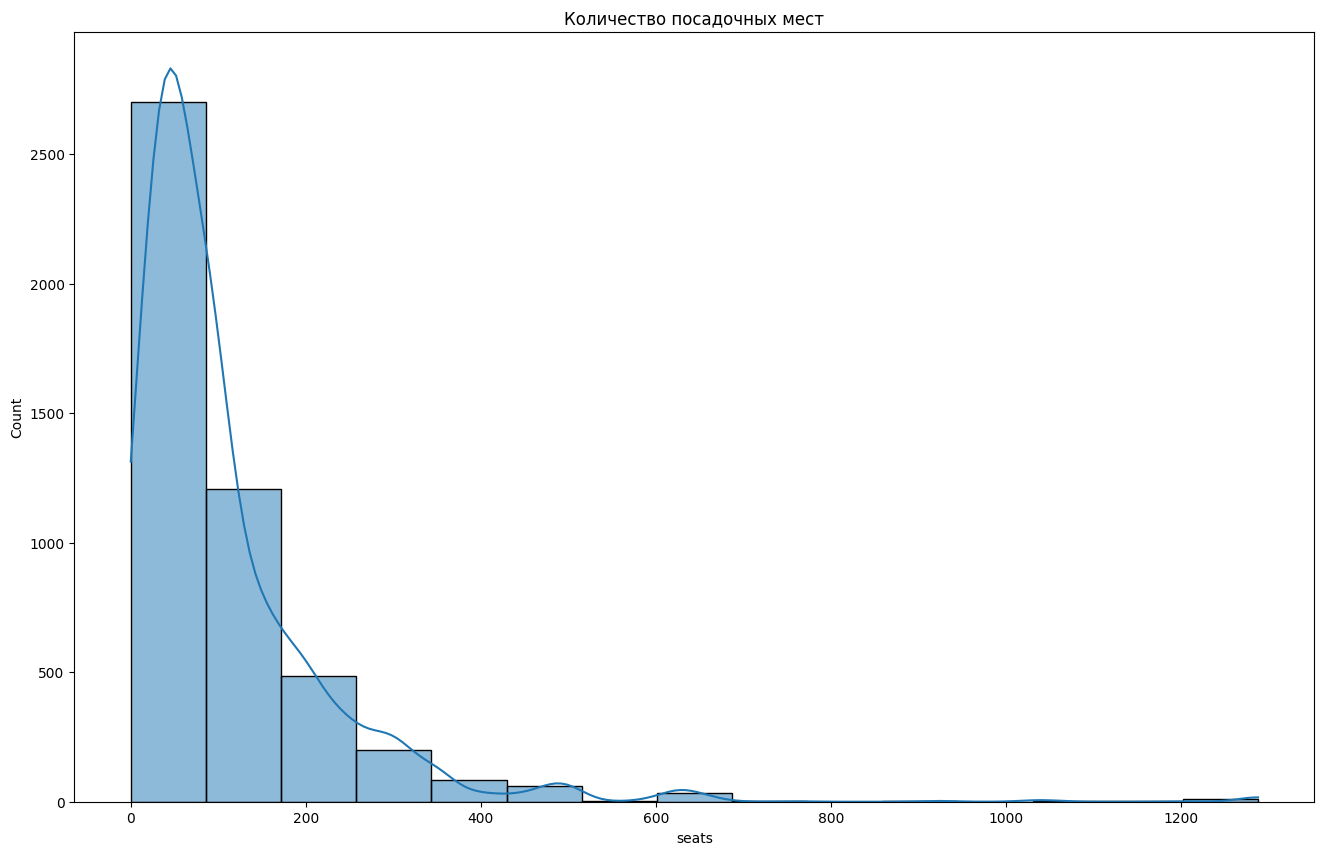

In [57]:
plt.figure(figsize=(16, 10))
sns.histplot(
    data=df_seats,
    x='seats',
    bins=15,
    kde=True,
)
plt.title('Количество посадочных мест')
plt.show()

**Наблюдения**

Гистограмма у нас правоассиметричного распределения. Правый хвост указывает на присутствие высоких значений, которые оттягивают распределение вправо.

Построим диаграмму размаха.

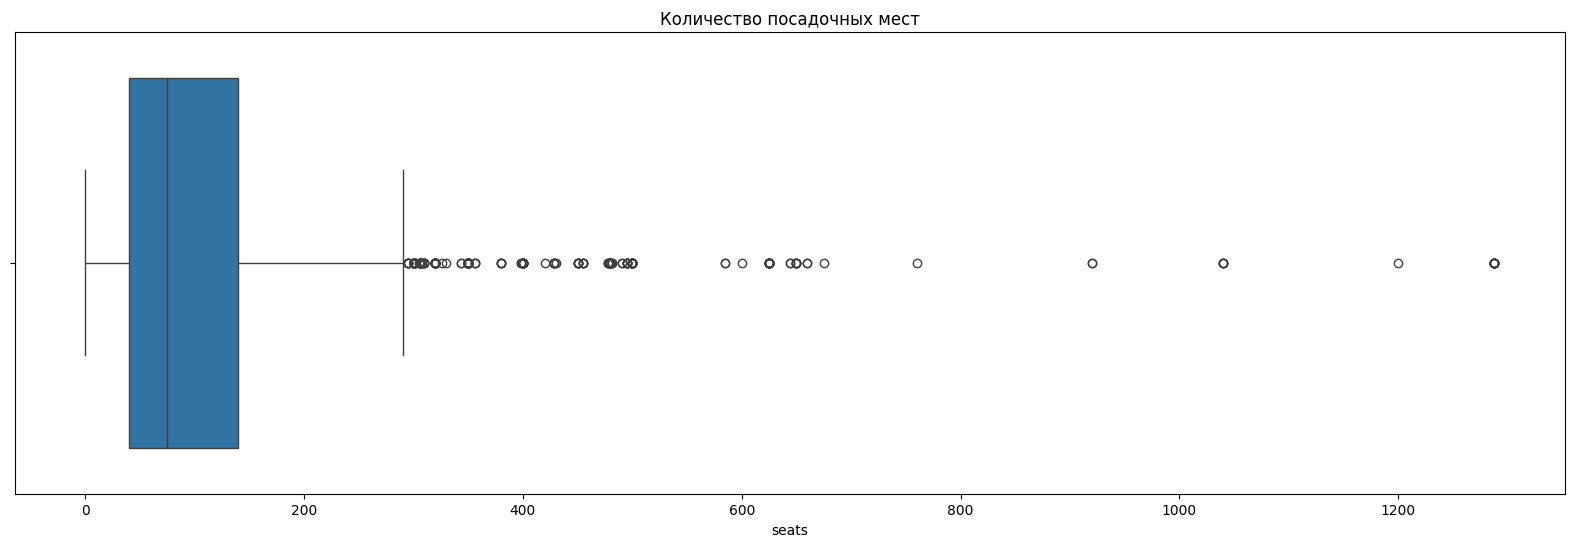

In [58]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=df_seats, x='seats')

plt.title('Количество посадочных мест')
plt.show()

Что мы здесь видим, как и на гистограмме у нас правоассиметричное распределение и есть выбросы, интересно посмотреть их поподробнее. Посмотрим, какие заведения у нас имеюют больше 1000 мест.

In [59]:
df_seats_filtered = df_seats.loc[df_seats['seats'] > 1000]

In [60]:
df_seats_filtered.shape[0]

16

In [61]:
df_seats_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
2713,8d07e2d1810b4dca9d4cb247d0335df3,ваня и гоги,"бар,паб","москва, измайловское шоссе, 71, корп. а",восточный административный округ,"ежедневно, 11:00–06:00",4.2,0,1040.0,высокие,средний счёт:1000–2500 ₽,1750.0,NaN,False
2722,4731af3e68bb449fb2b34493fadfaed1,маргарита,быстрое питание,"москва, измайловское шоссе, 71, корп. а",восточный административный округ,"ежедневно, 10:00–22:00",4.3,1,1040.0,NaN,NaN,NaN,NaN,False
2770,4c196f841b0046b3ab3a60d3ed52bfc5,шоколадница,кофейня,"москва, измайловское шоссе, 71, корп. а",восточный административный округ,"пн-ср 11:00–23:00; чт 11:00–00:00; пт,сб 11:00...",4.1,1,1040.0,NaN,NaN,NaN,NaN,False
2966,6b611f2fc2084078952aaef40780f11c,матрешка,кафе,"москва, измайловское шоссе, 71, корп. а",восточный административный округ,NaN,4.0,0,1040.0,NaN,NaN,NaN,NaN,False
4231,30d6c2abb42748bb98c01b1ed366e253,рестобар argomento,столовая,"москва, кутузовский проспект, 41, стр. 1",западный административный округ,"ежедневно, 12:00–23:00",4.2,0,1200.0,высокие,средний счёт:2500–5000 ₽,3750.0,NaN,False
6518,fbf22d98b62a47fbb2a71be3545f16b2,delonixcafe,ресторан,"москва, проспект вернадского, 94, корп. 1",западный административный округ,"ежедневно, круглосуточно",4.1,0,1288.0,высокие,средний счёт:1500–2000 ₽,1750.0,NaN,True
6524,c93d20f53072495c9cf2e489914cb8a5,ян примус,ресторан,"москва, проспект вернадского, 121, корп. 1",западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,1,1288.0,выше среднего,средний счёт:1500 ₽,1500.0,NaN,False
6574,5925d9677fe24778a27e35ccd88c0a2d,мюнгер,пиццерия,"москва, проспект вернадского, 97, корп. 1",западный административный округ,"пн-пт 08:00–21:00; сб,вс 10:00–21:00",4.8,1,1288.0,NaN,NaN,NaN,NaN,False
6641,0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"москва, проспект вернадского, 84, стр. 1",западный административный округ,"ежедневно, 08:30–20:00",4.3,1,1288.0,NaN,NaN,NaN,NaN,False
6658,19a223ff04f74af7a12bd87b77ce468b,гудбар,"бар,паб","москва, проспект вернадского, 97, корп. 1",западный административный округ,"пн-пт 11:00–23:00; сб,вс 13:00–23:00",4.1,0,1288.0,средние,средний счёт:700 ₽,700.0,NaN,False


Интересная картина, как-будто у нас закрались ошибки в этих данных. Одно и тоже значение **1288** для разного рода заведений. Возьмем к примеру:
* `one price coffee` - здесь как-будто по логике должно быть до 30 мест, если вообще не должно быть;
* `яндекс лавка` - если мы говорим о сервисе доставке еды, то тут он никак не может быть:
  * Рестораном;
  * Иметь 1288 мест.
  
Интересно посмотреть промежуток теперь между 600 и 1000 мест.

In [62]:
df_seats_filtered = df_seats.loc[(df_seats['seats'] > 600) & (df_seats['seats'] < 1000)]
df_seats_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
1326,83575e8d81064584ab791877c9d5389c,нам,"бар,паб","москва, ленинградский проспект, 69, стр. 1",северный административный округ,"ежедневно, 11:00–21:00",4.2,1,625.0,NaN,NaN,NaN,NaN,False
1351,9d703f8cdfb7487abbad137d19083ad0,максима пицца,пиццерия,"москва, ленинградский проспект, 78, корп. 1",северный административный округ,"пн-пт 09:00–00:00; сб,вс 10:00–00:00",4.3,0,625.0,выше среднего,средний счёт:1500–1800 ₽,1650.0,NaN,False
1355,e925b8a0c4c54f24b5fa008f28ff0482,страдивари,ресторан,"москва, ленинградский проспект, 77, корп. 1",северный административный округ,"ежедневно, 11:00–23:00",4.2,1,625.0,выше среднего,средний счёт:1000–2000 ₽,1500.0,NaN,False
1367,0884fb8437f848f98677d3d4b92ae23d,академия,пиццерия,"москва, ленинградский проспект, 72, корп. 1",северный административный округ,"пн-пт 09:00–23:00; сб,вс 11:00–23:00",4.2,1,625.0,средние,средний счёт:1000–1200 ₽,1100.0,NaN,False
1380,b8e5cece843a4a52851b12ac8e90bdef,север-метрополь,кофейня,"москва, ленинградский проспект, 75, корп. 1",северный административный округ,"ежедневно, 09:00–21:00",4.6,1,625.0,NaN,NaN,NaN,NaN,False
1385,59bbf92f93264dcead4e82e7b1f47375,чайхона на соколе,кафе,"москва, ленинградский проспект, 69, стр. 1",северный административный округ,"ежедневно, 08:00–23:00",4.3,0,625.0,средние,средний счёт:400–800 ₽,600.0,NaN,False
1393,092f8e43dc874599817610c5652fbb59,кулинарная лавка братьев караваевых,кафе,"москва, ленинградский проспект, 72, корп. 1",северный административный округ,"ежедневно, 08:00–23:00",4.3,1,625.0,NaN,средний счёт:500–800 ₽,650.0,NaN,False
1442,f5e9f3b1e90e44239e01afc8d2e26c52,abc coffee roasters,кофейня,"москва, ленинградский проспект, 72, корп. 1",северный административный округ,"пн-пт 08:00–22:00; сб,вс 10:00–22:00",4.5,0,625.0,средние,цена чашки капучино:220–270 ₽,NaN,245.0,False
1446,e023394d550c4f7997465e57514769eb,9 bar coffee,кофейня,"москва, ленинградский проспект, 80, корп. 1",северный административный округ,"пн-пт 07:30–21:00; сб,вс 07:30–19:00",4.3,1,625.0,NaN,цена чашки капучино:60–150 ₽,NaN,105.0,False
1464,1ca4b001c1a54dcebaa7e69a1b6ca0c7,находка,ресторан,"москва, ленинградский проспект, 74, корп. 1",северный административный округ,"ежедневно, 09:00–22:00",4.9,1,625.0,NaN,NaN,NaN,NaN,False


И заодно посмотрим промежуток между 400 и 600 мест.

In [63]:
df_seats_filtered = df_seats.loc[(df_seats['seats'] > 400) & (df_seats['seats'] < 600)]
df_seats_filtered

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
898,65bac088dfbb4a4e951378291da55c45,ош,кафе,"москва, ярославское шоссе, 114, корп. 1",северо-восточный административный округ,пн-сб 09:00–23:00; вс 10:00–22:00,4.3,1,500.0,NaN,NaN,NaN,NaN,False
1064,0669ac8b94d04dd9a5c61619c87013ff,восток,кафе,"москва, ярославское шоссе, 19, стр. 1",северо-восточный административный округ,"ежедневно, 10:00–18:00",4.3,1,500.0,NaN,NaN,NaN,NaN,False
1113,6e4040fc95b745de83803aebbd12e1f6,кафе при азс,кафе,"москва, ярославское шоссе, 1, корп. 1",северо-восточный административный округ,NaN,3.5,0,500.0,NaN,NaN,NaN,NaN,False
1752,dae4ff8361f644358bb9c9617a8a8f95,soul in the bowl,ресторан,"москва, лесная улица, 20, стр. 3",центральный административный округ,"ежедневно, 10:00–23:00",4.7,1,500.0,средние,средний счёт:700–850 ₽,775.0,NaN,False
1792,76f147374e874167acb8f40457859d7b,бансонс бургер китчен,ресторан,"москва, лесная улица, 20, стр. 3",центральный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–02:00; вс 10:00...",5.0,0,500.0,NaN,средний счёт:500–1000 ₽,750.0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8110,2a3d26a00489437580c09ff3c9e360bf,лавка daily,кафе,"москва, улица ленинская слобода, 19",южный административный округ,пн-пт 07:30–19:30,4.4,0,450.0,NaN,NaN,NaN,NaN,False
8171,df7865df18e84477a94dd424e372b94d,монстер хиллс,ресторан,"москва, автозаводская улица, 18",южный административный округ,"ежедневно, 10:00–22:00",4.0,0,455.0,средние,средний счёт:600–1200 ₽,900.0,NaN,False
8198,5cc55d53a83547e588d403c5ada1d28f,милти,быстрое питание,"москва, улица ленинская слобода, 19",южный административный округ,пн-пт 09:00–19:00,3.8,0,450.0,NaN,NaN,NaN,NaN,False
8237,dbc3aeaf0a8543da966d01ce432d48c9,pasta cup & pinsa,пиццерия,"москва, автозаводская улица, 18",южный административный округ,"ежедневно, 10:00–22:00",3.5,0,455.0,средние,средний счёт:450–700 ₽,575.0,NaN,False


Встречаются не логичные данные, больше похоже на ошибку заполнения. Изначально была мысль, что действительно небольшое количество заведений с большим числом посадочных мест, но на деле больше похоже на ошибки в данных. Для второй части по распределения по категориям будем ориентироваться на медианные значения.

In [64]:
pivot_seats = pd.pivot_table(df, values='seats', index='category', aggfunc='median')
pivot_seats

,seats
category,
"бар,паб",82.5
булочная,50.0
быстрое питание,65.0
кафе,60.0
кофейня,80.0
пиццерия,55.0
ресторан,86.0
столовая,75.5


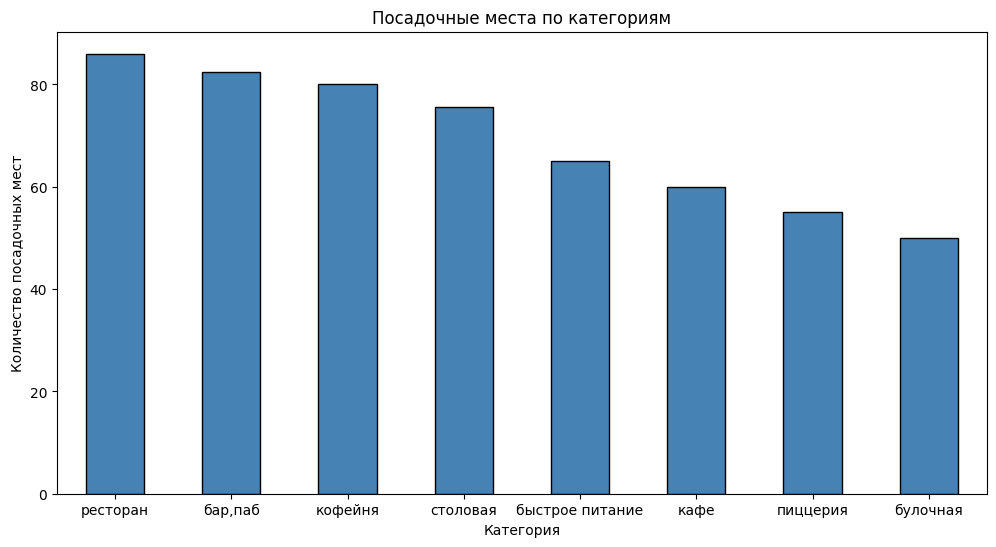

In [65]:
pivot_seats['seats'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12, 6),
    title='Посадочные места по категориям',
    legend=False,
    ylabel='Количество посадочных мест',
    xlabel='Категория',
    rot=0,
    color='#4682B4',
    edgecolor='black'
)
plt.show()

**Вывод по задаче**

По итогам исследования количества мест мы выявили, что в данных содержатся аномальные высокие значения. Эти значения появились скорее всего в следствии ошибочного заполнения данных. Для более точного анализа типичного количество мест мы воспользовались медианными значениями, которые мене чувствительны к выбросам и выявили, что значения колеблятся от 50 до 86 мест.

---

### Задача 5
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?</div>

Для начала посмотрим вообще на данные столбца рейтинг.

In [66]:
df['rating'].describe()

count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Видим, что распределение данных у нас в целом ровное. Посчитаем средний рейтинг по заведениям.

In [67]:
pivot_rating = pd.pivot_table(df, values='rating', index='category', aggfunc='mean')
pivot_rating

,rating
category,
"бар,паб",4.387712
булочная,4.268359
быстрое питание,4.050249
кафе,4.124284
кофейня,4.277282
пиццерия,4.301264
ресторан,4.290348
столовая,4.211429


И построим столбчатую диаграмму для визуализации распределения

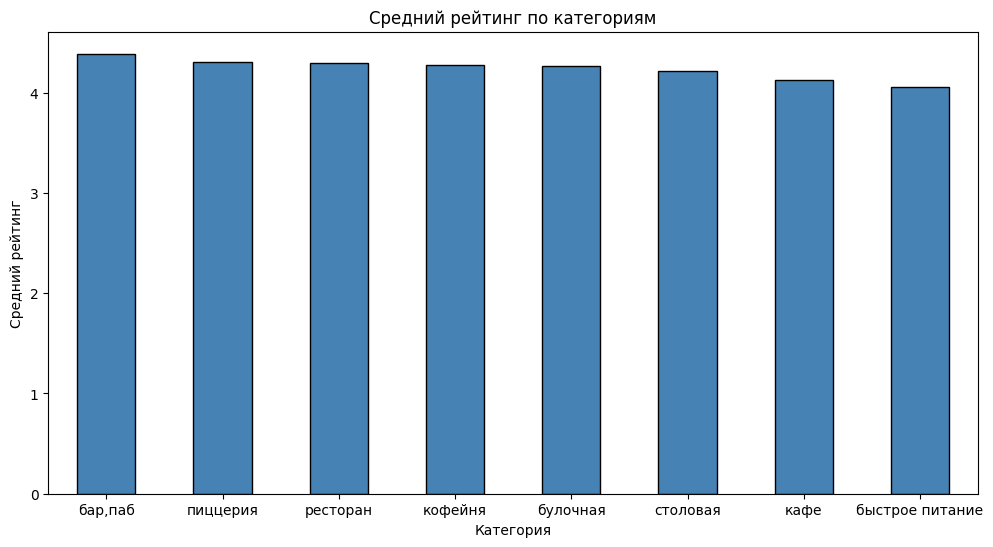

In [68]:
pivot_rating['rating'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12, 6),
    title='Средний рейтинг по категориям',
    legend=False,
    ylabel='Средний рейтинг',
    xlabel='Категория',
    rot=0,
    color='#4682B4',
    edgecolor='black'
)
plt.show()

**Вывод по задаче**

Средние рейтинги по категориям заведений у нас не сильно различаются, от **4** до **4.4**. Это говорит о том, что категория заведения не является определяющим фактором, влияющим на оценку посетителей.

---

### Задача 6
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.</div>

In [69]:
correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix(interval_cols=['rating', 'seats'])['rating']
correlation_matrix_rating = pd.DataFrame(correlation_matrix).drop('rating').sort_values(by='rating', ascending=False)
correlation_matrix_rating

,rating
price,0.262056
category,0.198763
district,0.189453
is_24_7,0.161010
chain,0.119212
seats,0.000000


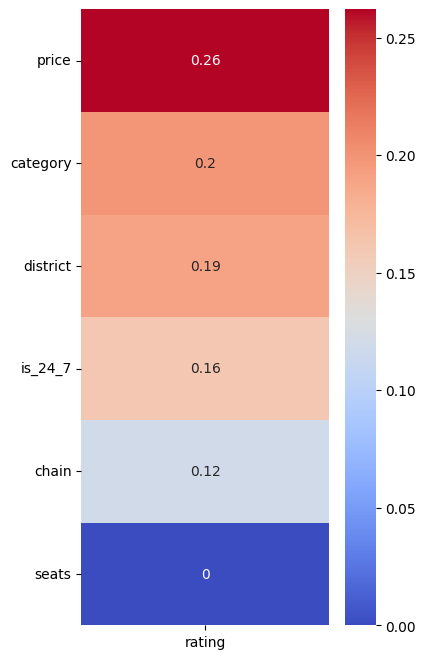

In [70]:
plt.figure(figsize=(4, 8))
sns.heatmap(correlation_matrix_rating, annot=True, cmap='coolwarm')
plt.yticks(rotation=0)
plt.show()

Самый высокий показатель корреляции у нас - взаимосвязь `rating` и `price`. Однако, само значение **0.26** говорит о слабой взаимосвязи, т.е. `price` практически не влияет на `rating`. 

In [71]:
price_rating = pd.pivot_table(df, values='rating', index='price', aggfunc='mean')
price_rating

,rating
price,
высокие,4.436611
выше среднего,4.386347
низкие,4.173077
средние,4.297874


Поскольку `price` имеет категориальный формат, самя простая визуализация тут будет столчатая диаграмма.

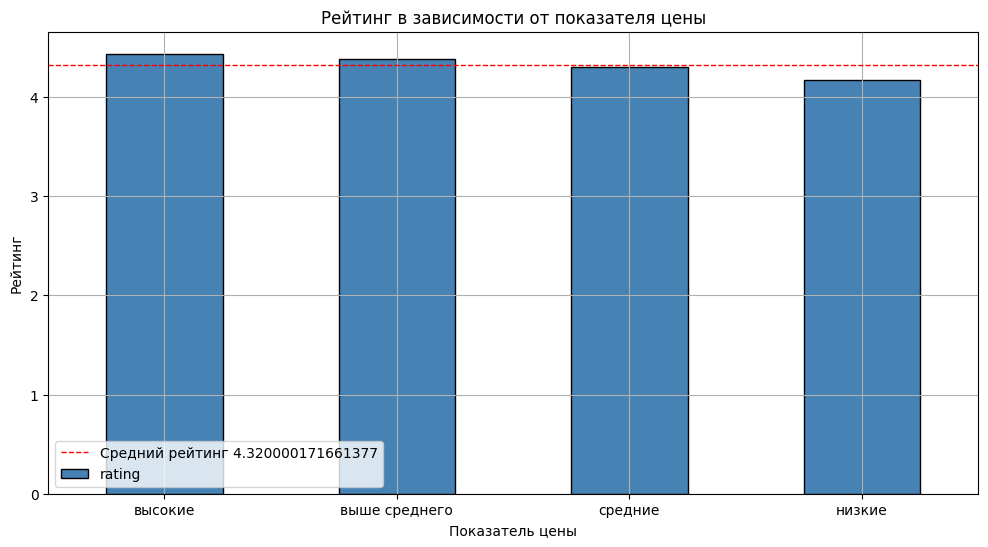

In [72]:
price_rating['rating'].sort_values(ascending=False).plot(
    kind='bar',
    legend=True,
    figsize=(12, 6),
    title='Рейтинг в зависимости от показателя цены',
    ylabel='Рейтинг',
    xlabel='Показатель цены',
    rot=0,
    color='#4682B4',
    edgecolor='black'
)
mean_rating = round(price_rating['rating'].mean(), 2)
plt.axhline(mean_rating,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Средний рейтинг {mean_rating}')
plt.grid()
plt.legend()
plt.show()

**Вывод по задаче**

Проанализировав влияние различных данных (категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным) на рейтинг заведения, мы выявили только условно **легкое** влияние цены на рейтинг.

---

### Задача 7

<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.</div>

Отберем сначала сетевые заведения

In [73]:
df_chain = df.loc[df['chain'] == 1]
df_chain.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,средний счёт:400–600 ₽,500.0,NaN,False
13,aea18265b0a0415893f1e796b82568fe,буханка,булочная,"москва, базовская улица, 15, корп. 1",северный административный округ,"ежедневно, 08:00–22:00",4.8,1,180.0,NaN,NaN,NaN,NaN,False
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",северный административный округ,"ежедневно, круглосуточно",4.4,1,NaN,NaN,NaN,NaN,NaN,True
20,1ab5691e4da844d3abadf085e0957852,чебуреки манты,кафе,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",4.3,1,148.0,NaN,NaN,NaN,NaN,False
23,78709462f2b3480f825489a5321a3563,буханка,булочная,"москва, лобненская улица, 13к2",северный административный округ,"ежедневно, 08:00–22:00",4.7,1,NaN,NaN,NaN,NaN,NaN,False


Сведем нужные нам данные в одну таблицу

In [74]:
top_name_rating = pd.pivot_table(df_chain, values=['id', 'rating'], index=['name'], aggfunc={'id':'count', 'rating':'mean'}).sort_values(by='id', ascending=False)
top_name_rating.columns = ['count', 'avg_rating']
total_rating = top_name_rating.head(15)
total_rating

,count,avg_rating
name,,
шоколадница,120,4.177500
домино'с пицца,76,4.169737
додо пицца,74,4.286487
one price coffee,71,4.064789
яндекс лавка,69,3.872464
cofix,65,4.075385
prime,50,4.116000
хинкальная,44,4.322727
кофепорт,42,4.147619


Построим диаграмму популярности

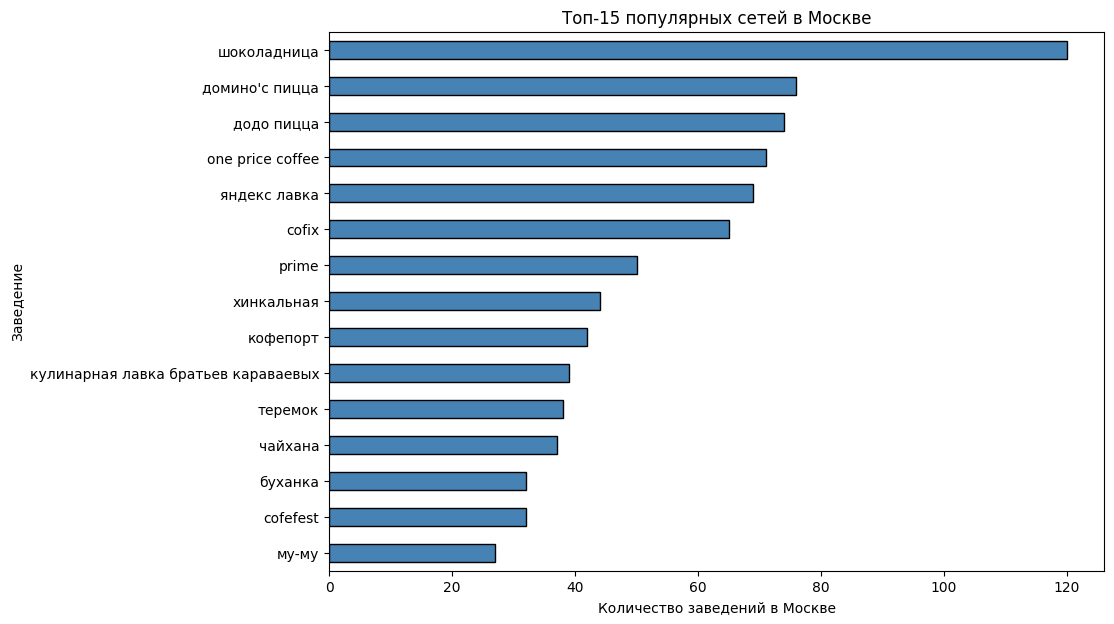

In [75]:
total_rating['count'].sort_values().plot(
    kind='barh',
    figsize=(10, 7),
    title=f'Топ-15 популярных сетей в Москве',
    legend=False,
    rot=0,
    color='#4682B4',
    edgecolor='black'
)
plt.xlabel('Количество заведений в Москве')
plt.ylabel('Заведение')
plt.show()

Построим диаграмму рейтинга и для наглядности наложим на нее средний рейтинг из всех данных

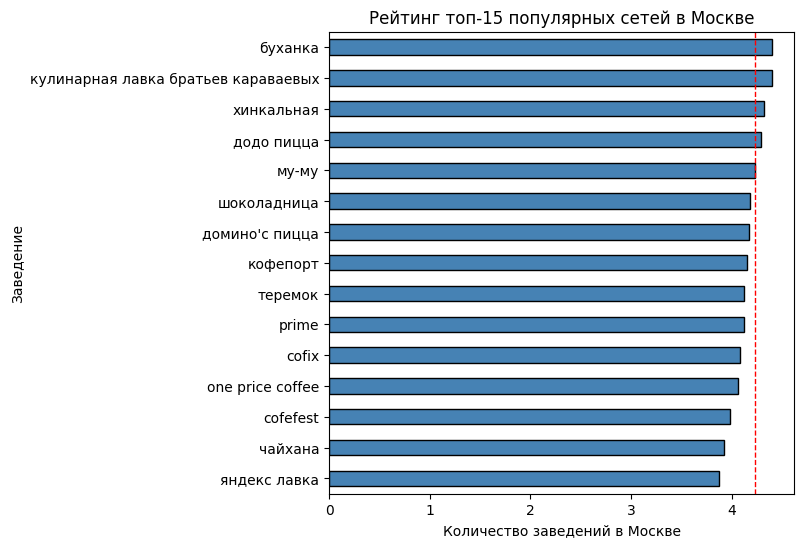

In [76]:
total_rating['avg_rating'].sort_values(ascending=True).plot(
    kind='barh',
    figsize=(6, 6),
    title=f'Рейтинг топ-15 популярных сетей в Москве',
    legend=False,
    rot=0,
    color='#4682B4',
    edgecolor='black'
)

mean_total_rating = df['rating'].mean()

plt.axvline(
    mean_total_rating,
    color='red',
    linestyle='--',
    linewidth=1
)

plt.xlabel('Количество заведений в Москве')
plt.ylabel('Заведение')
plt.show()

Проанализируем теперь категории

In [77]:
top_name_cat_rating = pd.pivot_table(df_chain, values=['id', 'category'], index='name', aggfunc={'id':'count', 'category':'max'}).sort_values(by=['id'], ascending=False)
top_name_cat_rating.columns = ['category', 'count']
total_cat_rating = top_name_cat_rating.head(15)
total_cat_rating

,category,count
name,,
шоколадница,кофейня,120
домино'с пицца,пиццерия,76
додо пицца,пиццерия,74
one price coffee,кофейня,71
яндекс лавка,ресторан,69
cofix,кофейня,65
prime,ресторан,50
хинкальная,столовая,44
кофепорт,кофейня,42


In [78]:
category_sum = total_cat_rating.groupby('category')['count'].sum().sort_values(ascending=False)
category_sum

category
кофейня     362
ресторан    194
пиццерия    150
столовая     71
кафе         39
Name: count, dtype: int64

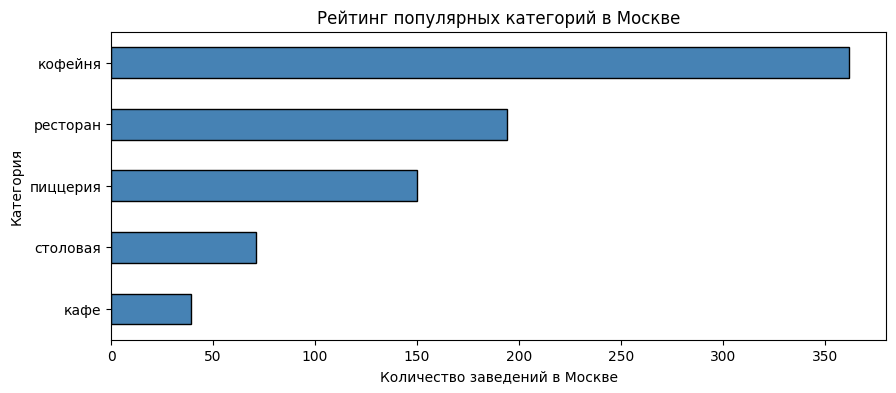

In [79]:
category_sum.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(10, 4),
    title=f'Рейтинг популярных категорий в Москве',
    legend=False,
    rot=0,
    color='#4682B4',
    edgecolor='black'
)

plt.xlabel('Количество заведений в Москве')
plt.ylabel('Категория')
plt.show()

**Вывод по задаче**

Мы проанализировали топ 15 сетевых заведений в Москве. Среди них выделяются **Шоколадница**, **Домино'с пицца** и **Додо пицца**. Но что интересно, хоть они и в лидерах и представляют 2 категории **Кофейня** и **Пиццерия**, тем не менее сама категория **Пиццерия** не так распространена, как рестораны.

---

### Задача 8
<br>
<div style="background-color: #FFEBCD; border-left: 5px solid #DAA520; padding: 15px">
Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.</div>

Поскольку у нас не все данне есть по среднему чеку, сделаем отдельный датафрейм для анализа только с заполненными данными `middle_avg_bill`.

In [80]:
df_middle_bill = df.loc[df['middle_avg_bill'].notna()]
df_middle_bill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3149 entries, 1 to 8403
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3149 non-null   object 
 1   name               3149 non-null   object 
 2   category           3149 non-null   object 
 3   address            3149 non-null   object 
 4   district           3149 non-null   object 
 5   hours              3143 non-null   object 
 6   rating             3149 non-null   float32
 7   chain              3149 non-null   int8   
 8   seats              1990 non-null   float32
 9   price              2679 non-null   object 
 10  avg_bill           3149 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  0 non-null      float32
 13  is_24_7            3149 non-null   bool   
dtypes: bool(1), float32(4), int8(1), object(8)
memory usage: 276.8+ KB


In [81]:
district_rating = pd.pivot_table(df_middle_bill, values='middle_avg_bill', index='district', aggfunc=['max', 'min', 'mean', 'median'])
district_rating.columns = ['max', 'min', 'mean', 'median']
district_rating

,max,min,mean,median
district,,,,
восточный административный округ,10000.0,50.0,820.626953,575.0
западный административный округ,5250.0,50.0,1053.225464,1000.0
северный административный округ,11000.0,130.0,927.959656,650.0
северо-восточный административный округ,4500.0,50.0,716.611267,500.0
северо-западный административный округ,2900.0,120.0,822.222900,700.0
центральный административный округ,7250.0,0.0,1191.057495,1000.0
юго-восточный административный округ,3750.0,30.0,654.097961,450.0
юго-западный административный округ,2750.0,100.0,792.561707,600.0
южный административный округ,35000.0,100.0,834.398071,500.0


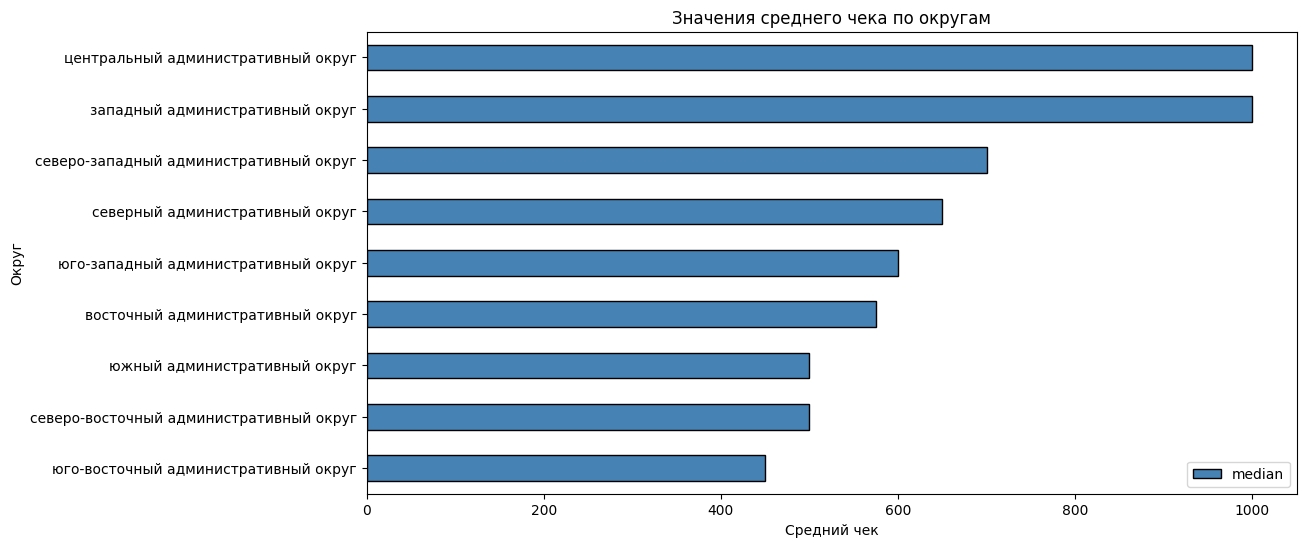

In [82]:
# Строим столбчатую диаграмму
district_rating['median'].sort_values().plot(
    kind='barh',
    figsize=(12, 6),
    title='Значения среднего чека по округам',
    legend=True,
    rot=0,
    color='#4682B4',
    edgecolor='black'
)
plt.xlabel('Средний чек')
plt.ylabel('Округ')
plt.show()

Выделим отдельно значения среднего и медианы.

In [83]:
discrict_avg_bill = district_rating[['mean', 'median']]
discrict_avg_bill.sort_values(by='mean', ascending=False)

,mean,median
district,,
центральный административный округ,1191.057495,1000.0
западный административный округ,1053.225464,1000.0
северный административный округ,927.959656,650.0
южный административный округ,834.398071,500.0
северо-западный административный округ,822.222900,700.0
восточный административный округ,820.626953,575.0
юго-западный административный округ,792.561707,600.0
северо-восточный административный округ,716.611267,500.0
юго-восточный административный округ,654.097961,450.0


Построим диаграмму для наглядного сравнения среднего значения чека и медианного значения чека внутри округа.

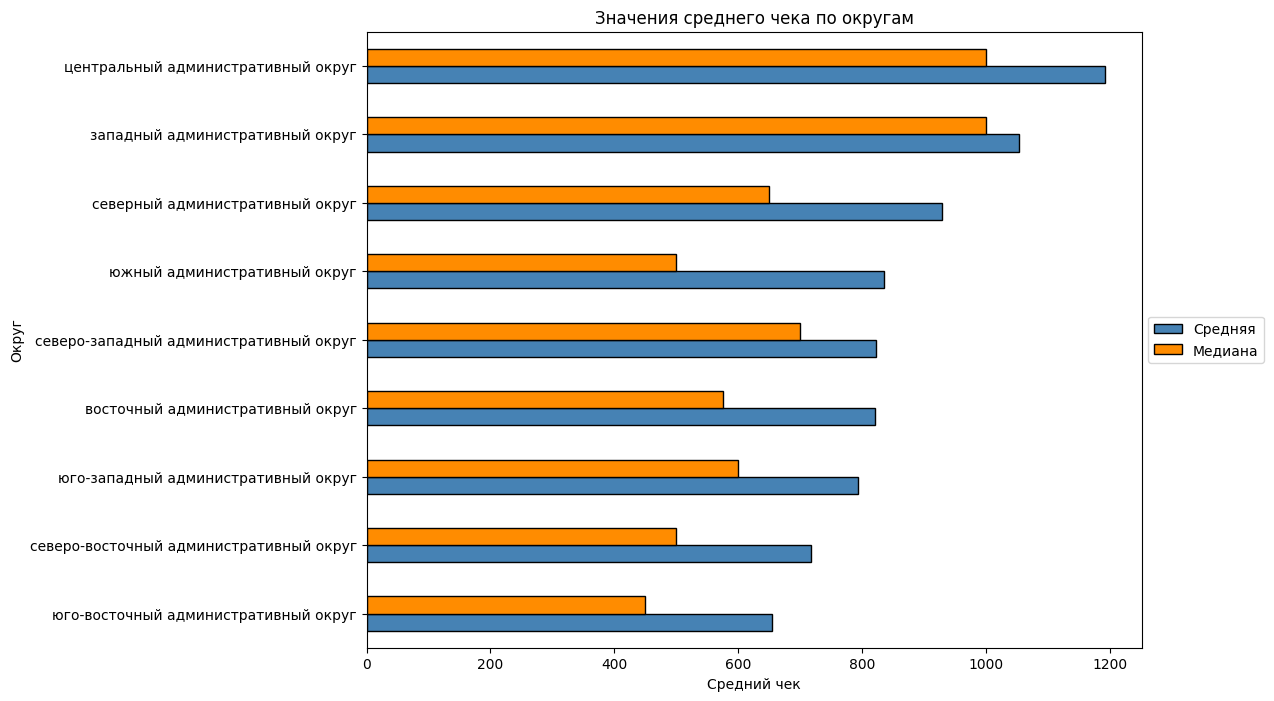

In [84]:
discrict_avg_bill[['mean', 'median']].sort_values(by='mean', ascending=True).plot(
    kind='barh',
    title='Значения среднего чека по округам',
    rot=0,
    figsize=(10, 8),
    color=['#4682B4', '#FF8C00'],
    edgecolor='black'
)
plt.xlabel('Средний чек')
plt.ylabel('Округ')
plt.legend(['Средняя', 'Медиана'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

**Вывод по задаче**

Проанализировав вариации среднего чека заведения по округам мы видим, что самый высокий у нас центральный округ, а за ним не отстает западный. А далее средний чек начинает снижаться. Но видимо начинает снижаться не из-за прямой удаленности от центра, а от условной "значимости" самого округа. Чем престижнее округ, тем цены и выше.

Интересная картина при сравнении среднего значения чека и медианного. Наглядно выделяется `Южный административный округ`. Если медианное значение его условно выравнивает с остальными округами, то среднее вытягивает вверх ближе к лидерам. На самом деле в каждом округе среднее значение выше медианного, предположим, что бывают иногда случаи больших чеков (например банкет, праздник и тд.), и значение максимального улетает вверх, что влияет на среднее значение.

### Промежуточный вывод

Обобщим полученные результаты:
1. Мы посмотрели, какими категориями у нас представленны данные и сколько объектов находиться в каждой категории. Видим, что в категории `кафе` самое большое количество объектов - `2376`.
2. Мы подсчитали количество объектов по округам Москвы - самое большое количество в `центральном административном округе`, `2242` объекта. А в самом центральном административном округе самая большая категория объектов - это `рестораны`, `670` объектов.
3. По общей картине мы видим, что сетевых заведений намного больше, чем не сетевых - **61.85%** против **38.15%**.
В разрезе категорий чаще всего сетевыми являются `булочная`, `пиццерия` и `кофейня`.
4. По итогам исследования количества мест мы выявили, что в данных содержатся аномальные высокие значения. Эти значения появились скорее всего в следствии ошибочного заполнения данных. Для более точного анализа типичного количество мест мы воспользовались медианными значениями, которые мене чувствительны к выбросам и выявили, что значения колеблятся от `50` до `86` мест.
5. Средние рейтинги по категориям заведений у нас не сильно различаются, от `4` до `4.4`. Это говорит о том, что категория заведения не является определяющим фактором, влияющим на оценку посетителей.
6. Проанализировав влияние различных данных (категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным) на рейтинг заведения, мы выявили только условно легкое влияние цены на рейтинг.
7. Мы проанализировали топ 15 сетевых заведений в Москве. Среди них выделяются `Шоколадница`, `Домино'с пицца` и `Додо пицца`. Но что интересно, хоть они и в лидерах и представляют 2 категории `кофейня` и `пиццерия`, тем не менее сама категория `пиццерия` уступает `ресторанам`.
8. Проанализировав вариации медианного чека заведения по округам мы види, что `самый высокий` у нас `центральный округ`, а за ним не отстает западный. А далее средний чек начинает снижаться. Но видимо начинает снижаться не из-за прямой удаленности от центра, а от условной `значимости` самого округа. Чем престижнее округ, тем цены и выше. При этом, если мы начинаем сравнивать средние значения, то они явно выше в каждом округе, что говорит о высоком значении максимального чека и в заведениях бывают иногда случаи больших чеков (например банкет, праздник и тд.).

---
## Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

**Общий обзор проделанной работы**

Проанализирован набор данных, содержащий сведения о заведениях общепита Москвы. Выполнена оценка структуры рынка по категориям заведений (кафе, рестораны, бары, пиццерии, кофейни и др.), их распределению по административным округам, соотношению сетевых и несетевых объектов, характерной вместимости, средним рейтингам и ценовому уровню. Проверено влияние на рейтинг таких факторов, как категория, округ, сетевой статус, количество мест, ценовой сегмент и круглосуточный режим. Рассмотрены топ‑15 сетевых заведений и география среднего чека. Это позволило выявить зоны возможностей для нового заведения.

**Главные выводы**

1. Максимальное число объектов сконцентрировано в Центральном административном округе (2242). При этом внутри ЦАО наиболее распространенная категория - рестораны (670);
2. Доля сетевых заведений достигает 61,85%. Из них выделяются булочные, пиццерии и кофейни;
3. В топ-15 сетей доминируют «Шоколадница», «Домино’с Пицца» и «Додо Пицца», представляющие категории «кофейня» и «пиццерия». При этом в абсолютном выражении категория «рестораны» лидирует по общему количеству объектов в Москве;
4. Число посадочных мест колеблется в диапазоне от 50 до 86 в зависимости от категории;
5. Рейтинги заведений колеблятся в узком диапазоне, от 4.0 до 4.4. При этом очень мало фактором из данных (категория, расположение, сетевой статус, вместимость или круглосуточной работы) влияет на рейтинг, даже цена не сильно его корректирует;
6. Наивысший медианный чек зафиксирован в ЦАО, за ним с небольшим отрывом следует Западный округ. Далее чек снижается, но его величина определяется больше "статусом" и платежеспособностью аудитории конкретного округа.

**Рекомендации**

1. ЦАО конечно привлекательно, но не имея "больших" ресурсов на открытие, сложно будет конкурировать с сетевыми гигантами. Можно поначалу рассмотреть локации в соседних округах, например ЗАО;
2. Ориентироваться нужно на 50-80 мест в заведении;
3. Если развивать сеть, то цену нужно коррелировать в соответствии с округом;
4. Категория не сильно влияет на рейтинг и популярность, поэтому можно открыть то, к чему "душа лежит". А основной упор делать на качестве, уровне обслуживания и внутреннего уюта.